In [129]:
import random
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [130]:
num_boards = 17
num_cols = 5
num_rows = 5
num_numbers = ((num_cols * num_rows)-1)
max_selection = 75

class Board:
    def __init__(self):
        self.grid = [0]* num_numbers
        self.randomize_board()
        # self.display()

    def randomize_board(self):
        self.grid = random.sample(range(0, max_selection), num_numbers)

    def __eq__(self, other):
        # 1. Check if 'other' is actually a Board instance
        if not isinstance(other, Board):
            # Return NotImplemented lets Python try other comparison types
            return NotImplemented 
        
        # 2. Compare the contents regardless of order
        return set(self.grid) == set(other.grid)

    def display(self):
        print(f"{self.grid}, len={len(self.grid)}")

b = Board()
# b.display()

In [131]:
def create_boards(num_boards):
    boards = []
    boards_created = 0
    while boards_created < num_boards:
        board = Board()
        is_duplicate = False
        for existing_board in boards:
            if board == existing_board:
                is_duplicate = True
                break
        if not is_duplicate:
            boards.append(board)
            boards_created += 1
    # print(f"Created {len(boards)} unique boards.")
    return boards

In [144]:
# Play one game loop
boards = create_boards(num_boards)
def game_loop(boards, draw_numbers):
    # print(f"Playing Bingo! with {len(boards)} boards.")
    
    num_winners = 0
    winning_boards = []
    for i, number in enumerate(draw_numbers):
        # print(f"Draw {i}: Number {number}")
        boards_with_number = 0
        for j, board in enumerate(boards):
            # board.display()
            if number in board.grid:
                # print(f"Board {j} has number {number}!")
                boards_with_number += 1
                board.grid.remove(number)
                if len(board.grid) == 0:
                    # print(f"Board {j} wins after draw {i}!")
                    winning_boards.append(board)
        if len(winning_boards) > 0:
            break

    return winning_boards,  i

game_loop(boards=boards, draw_numbers=random.sample(range(0, max_selection), max_selection))

([<__main__.Board at 0x75cd22896840>, <__main__.Board at 0x75cd228960f0>], 67)

count    1000.000000
mean       66.138000
std         2.702269
min        51.000000
25%        65.000000
50%        67.000000
75%        68.000000
max        72.000000
dtype: float64

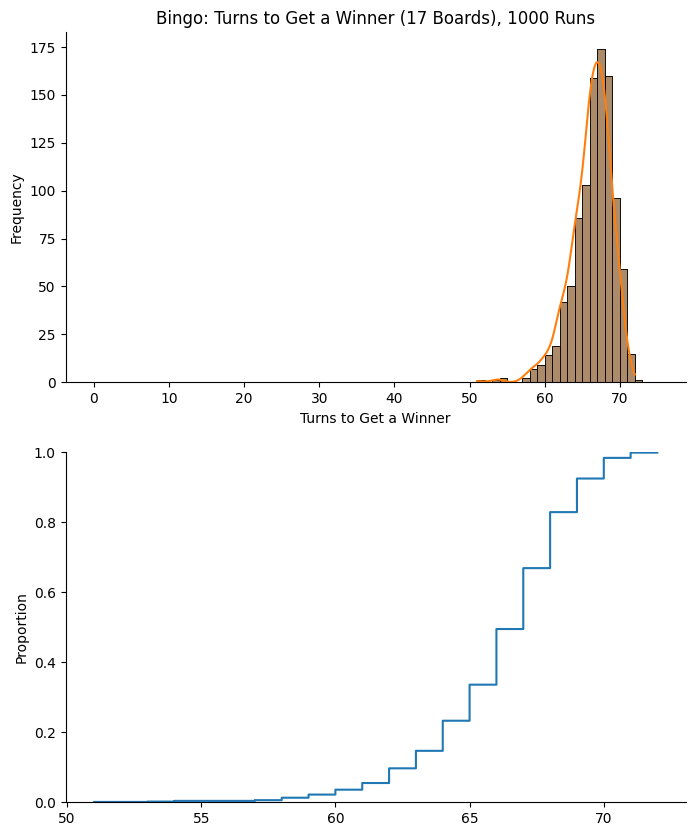

In [ ]:
turns_to_complete = []
number_of_winners = []
runs = int(1000)
for game in range(runs):
    print(f"Status: {game} / {runs} runs", end="\r", flush=True)
    boards = create_boards(num_boards)
    winning_boards, winning_turn = game_loop(boards=boards, draw_numbers=random.sample(range(0, max_selection), max_selection))
    if len(winning_boards) > 0:
        turns_to_complete.append(winning_turn)
        number_of_winners.append(len(winning_boards))
fig, ax = plt.subplots(2,1, figsize=(8,10))
sns.histplot(turns_to_complete, bins=range(0, max_selection+1), ax=ax[0])
sns.histplot(turns_to_complete, bins=range(0, max_selection+1), kde=True,ax=ax[0])
sns.despine(fig)
ax[0].set_title(f"Bingo: Turns to Get a Winner ({num_boards} Boards), {runs} Runs")
ax[0].set_xlabel("Turns to Get a Winner")
ax[0].set_ylabel("Frequency")

sns.ecdfplot(turns_to_complete, ax=ax[1])

# Convert the list to a Pandas Series
series = pd.Series(turns_to_complete)

# Get the summary
stats = series.describe()
display(stats)

sns.despine(fig)